<a href="https://colab.research.google.com/github/coweye1/CCMEO-Gunshot-Wound-Entrance-vs-Exit-CNN-ViT-CLIP-Benchmark/blob/main/CCMEO_Gunshot_Wound_Entrance_vs_Exit_CLIP_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Step 0: Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
# Step 1: Install necessary libraries and import modules
# 1부 라이브러리에 멀티모달(CLIP) 패키지를 통합하여 설치합니다.
!pip install timm scikit-learn pandas matplotlib tqdm openpyxl transformers open_clip_torch

import os
import zipfile
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset # CLIP 커스텀 데이터셋을 위해 Dataset 미리 임포트
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # 결과 시각화를 위해 미리 추가
from tqdm import tqdm
from PIL import Image # 이미지 로드를 위해 미리 추가

print("✅ Step 1: 모든 라이브러리와 멀티모달(CLIP) 패키지가 성공적으로 로드되었습니다.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
✅ Step 1: 모든 라이브러리와 멀티모달(CLIP) 패키지가 성공적으로 로드되었습니다.


In [3]:
# Step 2: Extract the zip file to the local Colab directory for faster training
import os
import zipfile
import time

# 구글 드라이브 폴더 목록을 조회하여 동기화 상태를 새로고침합니다.
try:
    print("🔄 구글 드라이브 동기화 상태 새로고침 중...")
    os.listdir('/content/drive/MyDrive')
except Exception as e:
    print(f"⚠️ 드라이브 접근 중 지연 발생: {e}")

zip_path = '/content/drive/MyDrive/CCMEO_Gunshot_Wound_Dataset.zip'
extract_path = '/content/CCMEO_Gunshot_Wound_Dataset'

if os.path.exists(zip_path):
    if not os.path.exists(extract_path):
        print("🚀 코랩 고속 가상 세션으로 데이터셋 압축 해제 시작 (안전 모드)...")
        start_time = time.time()

        # 대용량 파일 복사 및 전송 중 안정성을 위해 버퍼링 적용
        with open(zip_path, 'rb') as f:
            with zipfile.ZipFile(f) as zip_ref:
                zip_ref.extractall(extract_path)

        end_time = time.time()
        print(f"✅ Step 2: 데이터셋 압축 해제가 {end_time - start_time:.1f}초 만에 완벽하게 성공했습니다!")
    else:
        print("✅ Step 2: 데이터셋이 이미 가상 세션에 완벽하게 해제되어 있습니다.")
else:
    print("❌ [치명적 에러] 구글 드라이브 최상단에서 'CCMEO_Gunshot_Wound_Dataset.zip' 파일을 찾을 수 없습니다.")

🔄 구글 드라이브 동기화 상태 새로고침 중...
🚀 코랩 고속 가상 세션으로 데이터셋 압축 해제 시작 (안전 모드)...
✅ Step 2: 데이터셋 압축 해제가 15.2초 만에 완벽하게 성공했습니다!


In [10]:
# ==============================================================================
# 📊 Step 3: Load Existing Train/Val Folders and Map to CLIP (Path Bug Fixed)
# ==============================================================================
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CLIPFolderDataset(Dataset):
    def __init__(self, stage_dir, transform=None):
        """
        이미 train 폴더와 val 폴더로 나뉜 구조를 오차 없이 읽어옵니다.
        상위 폴더명에 방해받지 않도록 가장 하위 디렉토리명만 정밀 파싱합니다.
        """
        self.stage_dir = stage_dir
        self.transform = transform
        self.all_files = []
        self.img_labels = []

        # 하위 폴더 트리 전수조사
        for root, dirs, files in os.walk(stage_dir):
            for file in files:
                if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    full_path = os.path.join(root, file)

                    # [🚨 버그 수정] 전체 경로 대신 파일이 속한 '직계 하위 폴더명'만 추출
                    leaf_folder_name = os.path.basename(root).lower()
                    filename_lower = file.lower()

                    # 직계 폴더명이나 파일명 자체에서 키워드 검사
                    if 'entrance' in leaf_folder_name or filename_lower.startswith('en'):
                        label = 0
                    elif 'exit' in leaf_folder_name or filename_lower.startswith('ex'):
                        label = 1
                    else:
                        # 폴더명 기반 2차 방어선
                        if 'en' in leaf_folder_name:
                            label = 0
                        elif 'ex' in leaf_folder_name:
                            label = 1
                        else:
                            continue

                    self.all_files.append(full_path)
                    self.img_labels.append(label)

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        img_path = self.all_files[idx]
        label = self.img_labels[idx]

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        if label == 0:
            text_prompt = "A forensic autopsy photo of a gunshot entrance wound."
        else:
            text_prompt = "A forensic autopsy photo of a gunshot exit wound."

        return image, label, text_prompt

# ------------------------------------------------------------------------------
# 📂 실제 물리 폴더 경로 정의 및 데이터로더 생성
# ------------------------------------------------------------------------------
train_dir = '/content/CCMEO_Gunshot_Wound_Dataset/train'
val_dir = '/content/CCMEO_Gunshot_Wound_Dataset/val'

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = CLIPFolderDataset(stage_dir=train_dir, transform=base_transform)
val_dataset = CLIPFolderDataset(stage_dir=val_dir, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("\n" + "="*60)
print(f"✅ Step 3: [경로 버그 수정 완료] 물리 폴더 연동 성공!")
print(f"📦 훈련용(Train) 이미지: {len(train_dataset)} 장")
print(f"📦 검증용(Val) 이미지:   {len(val_dataset)} 장")

# 클래스 분포 분포가 정상적인지 전수 검사하여 리포트합니다.
train_labels = np.array(train_dataset.img_labels)
val_labels = np.array(val_dataset.img_labels)
print("-"*60)
print(f"📊 [데이터셋 클래스 밸런스 검증]")
print(f"  - Train 셋 -> 사입구(0): {np.sum(train_labels==0)}장 | 사출구(1): {np.sum(train_labels==1)}장")
print(f"  - Val 셋   -> 사입구(0): {np.sum(val_labels==0)}장 | 사출구(1): {np.sum(val_labels==1)}장")
print("="*60)


✅ Step 3: [경로 버그 수정 완료] 물리 폴더 연동 성공!
📦 훈련용(Train) 이미지: 1311 장
📦 검증용(Val) 이미지:   328 장
------------------------------------------------------------
📊 [데이터셋 클래스 밸런스 검증]
  - Train 셋 -> 사입구(0): 773장 | 사출구(1): 538장
  - Val 셋   -> 사입구(0): 206장 | 사출구(1): 122장


In [8]:
# ==============================================================================
# 🏗️ Step 4: Load Zero-shot 3-Model Lineup and Tokenizers (PLIP Path Patch)
# ==============================================================================
import torch
import random
import os
import numpy as np
import open_clip
from transformers import AutoModel, AutoProcessor, CLIPProcessor, CLIPModel

# 난수 시드 고정 및 GPU 디바이스 설정
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.enabled = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"⚡ 연산 디바이스 배정 완료: {device}")
print("🚀 Zero-shot 3대장 멀티모달 모델 및 토크나이저 로드 시작...")

# ------------------------------------------------------------------------------
# 1. General CLIP (일반 인터넷 상식 기반 - OpenAI)
# ------------------------------------------------------------------------------
print("  └ [1/3] General CLIP (OpenAI CLIP-ViT-B/32) 로드 중...")
general_model_name = "openai/clip-vit-base-patch32"
general_processor = CLIPProcessor.from_pretrained(general_model_name)
general_model = CLIPModel.from_pretrained(general_model_name).to(device)
general_model.eval()

# ------------------------------------------------------------------------------
# 2. BiomedCLIP (종합 의학 도메인 특화 - Microsoft)
# ------------------------------------------------------------------------------
print("  └ [2/3] BiomedCLIP (Microsoft BiomedCLIP-ViT-B/16) 로드 중...")
biomed_model, _, biomed_preprocess = open_clip.create_model_and_transforms(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
)
biomed_model = biomed_model.to(device)
biomed_model.eval()
biomed_tokenizer = open_clip.get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

# ------------------------------------------------------------------------------
# 3. PLIP (병리학 도메인 최적화 특화 - Stanford/PathCheck Official Path)
# ------------------------------------------------------------------------------
# [Patch] 401 에러 및 인증 요구를 원천 우회하는 퍼블릭 무결성 주소 'vinid/plip'으로 선언합니다.
print("  └ [3/3] PLIP (Pathology Language-Image Pretraining) 로드 중...")
plip_model_name = "vinid/plip"
plip_processor = AutoProcessor.from_pretrained(plip_model_name)
plip_model = AutoModel.from_pretrained(plip_model_name).to(device)
plip_model.eval()

print("\n" + "="*60)
print("✅ Step 4: Zero-shot 3대장 멀티모달 편대 로드 완료!")
print(f"  - Model 1: General CLIP (ViT-B/32) -> Ready")
print(f"  - Model 2: BiomedCLIP (ViT-B/16)  -> Ready")
print(f"  - Model 3: PLIP (ViT-B/16)        -> Ready")
print("="*60)

⚡ 연산 디바이스 배정 완료: cuda
🚀 Zero-shot 3대장 멀티모달 모델 및 토크나이저 로드 시작...
  └ [1/3] General CLIP (OpenAI CLIP-ViT-B/32) 로드 중...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  └ [2/3] BiomedCLIP (Microsoft BiomedCLIP-ViT-B/16) 로드 중...
  └ [3/3] PLIP (Pathology Language-Image Pretraining) 로드 중...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]


✅ Step 4: Zero-shot 3대장 멀티모달 편대 로드 완료!
  - Model 1: General CLIP (ViT-B/32) -> Ready
  - Model 2: BiomedCLIP (ViT-B/16)  -> Ready
  - Model 3: PLIP (ViT-B/16)        -> Ready


In [11]:
# ==============================================================================
# 🧠 Step 5 & 6: Zero-shot Inference Engine & Framework Setup
# ==============================================================================
# 각 모델의 고유 전처리 규격을 적용하여 실시간 검증(Validation)을 수행하는 마스터 함수입니다.

def evaluate_zero_shot_model(model_name, model, val_loader, device):
    """
    1부의 검증(Validation) 루프 감성을 그대로 계승하여,
    각 멀티모달 모델별로 사입구(Entrance) vs 사출구(Exit) 프롬프트 유사도를 계산해 성적을 뽑아냅니다.
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []  # ROC-AUC 계산을 위한 Exit(클래스 1) 확률 저장용

    # 6대 편대용 표준 프롬프트 정의 (Step 3에서 세팅한 문장과 완벽 대치)
    prompt_entrance = "A forensic autopsy photo of a gunshot entrance wound."
    prompt_exit = "A forensic autopsy photo of a gunshot exit wound."
    text_prompts = [prompt_entrance, prompt_exit]

    print(f"📊 [{model_name}] Zero-shot 벤치마크 평가 가동 중...")

    with torch.no_grad():
        # 1부 tqdm 포맷과 완벽하게 일치시킵니다.
        for images, labels, _ in tqdm(val_loader, desc=f"🔍 Evaluation ({model_name})"):
            # ------------------------------------------------------------------
            # A. 모델별 맞춤형 전처리 및 텍스트 토큰화 분기 프로세스
            # ------------------------------------------------------------------
            if model_name == "General CLIP":
                # General CLIP은 PIL 이미지 원본을 프로세서에 먹여 텐서로 변환해야 정밀합니다.
                # 데이터로더에서 나온 텐서를 다시 PIL 이미지 리스트로 복원하여 입력합니다.
                pil_images = [transforms.ToPILImage()(img) for img in images]
                inputs = general_processor(text=text_prompts, images=pil_images, return_tensors="pt", padding=True).to(device)

                outputs = model(**inputs)
                # 이미지-텍스트 유사도 로그값(Logits) 추출
                logits_per_image = outputs.logits_per_image  # Shape: [Batch_size, 2]
                probs = logits_per_image.softmax(dim=-1)     # Softmax로 확률 변환

            elif model_name == "BiomedCLIP":
                # BiomedCLIP은 전용 전처리(biomed_preprocess)와 토크나이저를 사용합니다.
                pil_images = [transforms.ToPILImage()(img) for img in images]
                image_tensors = torch.stack([biomed_preprocess(img) for img in pil_images]).to(device)
                text_tokens = biomed_tokenizer(text_prompts).to(device)

                # BiomedCLIP 전용 순전파 연산
                image_features, text_features, logit_scale = model(image_tensors, text_tokens)

                # 코사인 유사도 행렬곱 연산 수행
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)
                logits_per_image = (image_features @ text_features.T) * logit_scale.exp()
                probs = logits_per_image.softmax(dim=-1)

            elif model_name == "PLIP":
                # PLIP (vinid/plip) 오리지널 프로세서 전처리 가동
                pil_images = [transforms.ToPILImage()(img) for img in images]
                inputs = plip_processor(text=text_prompts, images=pil_images, return_tensors="pt", padding=True).to(device)

                outputs = model(**inputs)
                # PLIP은 오토모델 아키텍처 특성상 유사도 매트릭스를 직접 dot-product 해줍니다.
                image_features = outputs.image_embeds
                text_features = outputs.text_embeds

                # 정규화 후 유사도 스코어 산출
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)
                # 가중치 척도 100배 스케일링 적용 (OpenAI 표준 규격)
                logits_per_image = (image_features @ text_features.T) * 100.0
                probs = logits_per_image.softmax(dim=-1)

            # ------------------------------------------------------------------
            # B. 메트릭 데이터 수집 (1부 벤치마크 시스템과 100% 호환)
            # ------------------------------------------------------------------
            # 예측값: 확률이 더 높은 인덱스 (0: Entrance, 1: Exit)
            preds = torch.argmax(probs, dim=-1).cpu().numpy()
            exit_probs = probs[:, 1].cpu().numpy()  # Class 1 (Exit) 확률 추출

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(exit_probs)

    # --------------------------------------------------------------------------
    # C. 학술 통계 스펙 산출 (1부 연산 로직 엄격 준수)
    # --------------------------------------------------------------------------
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
    auc_score = roc_auc_score(all_labels, all_probs)
    fpr, tpr, _ = roc_curve(all_labels, all_probs)

    # 결과를 이쁘게 꾸러미로 패킹하여 리턴
    metrics_result = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc_score,
        "fpr": fpr,
        "tpr": tpr,
        "raw_preds": all_preds,
        "raw_labels": all_labels,
        "raw_probs": all_probs
    }

    return metrics_result

# ------------------------------------------------------------------------------
# 🏎️ 3대장 제로샷 편대 동시 출격 및 가동 테스트
# ------------------------------------------------------------------------------
# 성적표를 마스터 보드에 담기 위해 딕셔너리 셋업
zeroshot_results = {}

# 1. General CLIP 가동
zeroshot_results["General CLIP"] = evaluate_zero_shot_model("General CLIP", general_model, val_loader, device)

# 2. BiomedCLIP 가동
zeroshot_results["BiomedCLIP"] = evaluate_zero_shot_model("BiomedCLIP", biomed_model, val_loader, device)

# 3. PLIP 가동
zeroshot_results["PLIP"] = evaluate_zero_shot_model("PLIP", plip_model, val_loader, device)

# ------------------------------------------------------------------------------
# 📊 [Preview] 제로샷 3대장 임시 리더보드 출력
# ------------------------------------------------------------------------------
print("\n" + "="*60)
print("🏆 Zero-shot 3대장 편대 1차 벤치마크 결과 리더보드")
print("="*60)
for m_name, metrics in zeroshot_results.items():
    print(f"📌 [{m_name}]")
    print(f"  - Accuracy:  {metrics['accuracy']*100:.2f}%")
    print(f"  - F1-Score:  {metrics['f1']:.4f}")
    print(f"  - ROC-AUC:   {metrics['auc']:.4f}")
    print("-" * 40)
print("="*60)
print("✅ Step 5 & 6 성공! 제로샷 베이스라인 성적이 완벽하게 마크되었습니다.")

📊 [General CLIP] Zero-shot 벤치마크 평가 가동 중...


🔍 Evaluation (General CLIP): 100%|██████████| 11/11 [00:10<00:00,  1.00it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


📊 [BiomedCLIP] Zero-shot 벤치마크 평가 가동 중...


🔍 Evaluation (BiomedCLIP): 100%|██████████| 11/11 [00:13<00:00,  1.25s/it]


📊 [PLIP] Zero-shot 벤치마크 평가 가동 중...


🔍 Evaluation (PLIP): 100%|██████████| 11/11 [00:10<00:00,  1.01it/s]


🏆 Zero-shot 3대장 편대 1차 벤치마크 결과 리더보드
📌 [General CLIP]
  - Accuracy:  62.80%
  - F1-Score:  0.0000
  - ROC-AUC:   0.5746
----------------------------------------
📌 [BiomedCLIP]
  - Accuracy:  36.28%
  - F1-Score:  0.5324
  - ROC-AUC:   0.4877
----------------------------------------
📌 [PLIP]
  - Accuracy:  52.13%
  - F1-Score:  0.4567
  - ROC-AUC:   0.5520
----------------------------------------
✅ Step 5 & 6 성공! 제로샷 베이스라인 성적이 완벽하게 마크되었습니다.


In [13]:
# ==============================================================================
# 🛠️ Step 7: Define Fine-tuning Architecture, Loss Function, and Optimizer for PLIP
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchvision import transforms

class FineTunePLIPClassifier(nn.Module):
    def __init__(self, plip_model):
        super(FineTunePLIPClassifier, self).__init__()
        # PLIP의 오리지널 이미지 인코더 백본만 그대로 추출합니다.
        self.image_encoder = plip_model.vision_model

        # PLIP ViT-Base의 임베딩 히든 디멘션은 768 차원입니다.
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2) # 0: Entrance, 1: Exit 이진 분류 항목
        )

    def forward(self, pixel_values):
        outputs = self.image_encoder(pixel_values=pixel_values)
        feat = outputs.pooler_output
        logits = self.classifier(feat)
        return logits

# ------------------------------------------------------------------------------
# 🏗️ 모델 빌드 및 1부 스펙 기준 클래스 불균형 손실함수 세팅
# ------------------------------------------------------------------------------
print("🏭 PLIP 기반 법의학 커스텀 분류 모델 빌드 중...")
ft_plip_model = FineTunePLIPClassifier(plip_model).to(device)

# [🚨 버그 수정] Subset 참조 구조를 걷어내고, 독립 인스턴스에서 레이블을 다이렉트로 파싱합니다.
train_labels_arr = np.array(train_dataset.img_labels)
class_counts = np.bincount(train_labels_arr)
class_weights = 1.0 / class_counts
class_weights = class_weights / np.sum(class_weights) * 2.0  # 스케일 정규화
ft_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=ft_weights)

# ------------------------------------------------------------------------------
# 🏎️ 하이퍼파라미터 및 AdamW 최적화 가속기 설정
# ------------------------------------------------------------------------------
LEARNING_RATE = 2e-5
EPOCHS = 5  # 과적합 방지 및 T4 가속 세션을 고려한 최적 에포크

optimizer = optim.AdamW(ft_plip_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# PLIP 순정 해상도 규격(224x224) 및 ImageNet 정규화 가속 픽스
plip_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

plip_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 실제 파인튜닝에 사용될 무결성 트랜스폼 주입
train_dataset.transform = plip_transform
val_dataset.transform = plip_val_transform

print("\n" + "="*60)
print("✅ Step 7: PLIP 파인튜닝 모델 및 손실 함수/옵티마이저 구성 완료!")
print(f"  - 계산된 클래스 가중치: 사입구(0)={ft_weights[0]:.4f} | 사출구(1)={ft_weights[1]:.4f}")
print(f"  - 초기 학습률(LR): {LEARNING_RATE} | 총 에포크 수: {EPOCHS}")
print("="*60)

🏭 PLIP 기반 법의학 커스텀 분류 모델 빌드 중...

✅ Step 7: PLIP 파인튜닝 모델 및 손실 함수/옵티마이저 구성 완료!
  - 계산된 클래스 가중치: 사입구(0)=0.8207 | 사출구(1)=1.1793
  - 초기 학습률(LR): 2e-05 | 총 에포크 수: 5


In [14]:
# ==============================================================================
# 🎯 Step 8: Core Fine-tuning Training & Validation Loop (PLIP Forensic Edition)
# ==============================================================================
# 1부의 정밀 트래킹 학습 엔진을 오마주하여, 최적의 가중치를 실시간으로 포착하고 저장합니다.

import time

# 최적의 모델 가중치를 저장할 경로 및 초기화
best_model_path = 'best_plip_forensic_model.pth'
best_val_acc = 0.0

print("🔥 PLIP 이미지 백본 파인튜닝 공장 가동 (Target: Gunshot Entrance vs Exit) ...")
print("=" * 70)

for epoch in range(EPOCHS):
    start_time = time.time()

    # ------------------------------------------------------------------
    # 🏃‍♂️ 1. Training Phase (학습 단계)
    # ------------------------------------------------------------------
    ft_plip_model.train()
    train_loss = 0.0
    train_preds = []
    train_true = []

    # tqdm 진행 바를 1부 스펙과 완벽하게 일치시킵니다.
    for images, labels, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # 순전파 (Forward Pass)
        logits = ft_plip_model(pixel_values=images)
        loss = criterion(logits, labels)

        # 역전파 및 가중치 업데이트
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        # 정확도 계산을 위한 데이터 수집
        preds = torch.argmax(logits, dim=-1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    # 코사인 스케줄러 단계 갱신
    scheduler.step()

    # 에포크별 Train 메트릭 최종 정산
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = accuracy_score(train_true, train_preds)

    # ------------------------------------------------------------------
    # 👁️‍🗨️ 2. Validation Phase (검증 단계)
    # ------------------------------------------------------------------
    ft_plip_model.eval()
    val_loss = 0.0
    val_preds = []
    val_true = []

    with torch.no_grad():
        for images, labels, _ in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            images = images.to(device)
            labels = labels.to(device)

            logits = ft_plip_model(pixel_values=images)
            loss = criterion(logits, labels)

            val_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    # 에포크별 Validation 메트릭 최종 정산
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = accuracy_score(val_true, val_preds)

    epoch_duration = time.time() - start_time

    # ------------------------------------------------------------------
    # 📈 3. 에포크 결과 리포트 및 최고 성적 가중치 실시간 저장
    # ------------------------------------------------------------------
    print(f"\n📢 [Epoch {epoch+1:02d}] 완료 ({epoch_duration:.1f}초 소요)")
    print(f"  - Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}%")
    print(f"  - Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc*100:.2f}%")

    # Validation Accuracy 기준으로 최고 성능 모델 스냅샷 저장
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(ft_plip_model.state_dict(), best_model_path)
        print(f"  🌟 [BEST] 최고 검증 정확도 경신! 최적 가중치가 '{best_model_path}'로 저장되었습니다.")

    print("-" * 70)

print("\n" + "="*70)
print(f"🏁 파인튜닝 공장 가동 종료! 최종 에포크 최고 검증 정확도(Best Val Acc): {best_val_acc*100:.2f}%")
print("="*70)

🔥 PLIP 이미지 백본 파인튜닝 공장 가동 (Target: Gunshot Entrance vs Exit) ...


Epoch 1/5 [Val]: 100%|██████████| 11/11 [00:09<00:00,  1.13it/s]



📢 [Epoch 01] 완료 (65.8초 소요)
  - Train Loss: 0.5962 | Train Acc: 67.12%
  - Val Loss:   0.6414 | Val Acc:   64.02%
  🌟 [BEST] 최고 검증 정확도 경신! 최적 가중치가 'best_plip_forensic_model.pth'로 저장되었습니다.
----------------------------------------------------------------------


Epoch 2/5 [Val]: 100%|██████████| 11/11 [00:10<00:00,  1.06it/s]



📢 [Epoch 02] 완료 (51.6초 소요)
  - Train Loss: 0.5012 | Train Acc: 75.74%
  - Val Loss:   0.7964 | Val Acc:   54.88%
----------------------------------------------------------------------


...


📢 [Epoch 03] 완료 (50.4초 소요)
  - Train Loss: 0.4010 | Train Acc: 82.99%
  - Val Loss:   0.4522 | Val Acc:   79.88%
  🌟 [BEST] 최고 검증 정확도 경신! 최적 가중치가 'best_plip_forensic_model.pth'로 저장되었습니다.
----------------------------------------------------------------------


Epoch 4/5 [Val]: 100%|██████████| 11/11 [00:09<00:00,  1.15it/s]



📢 [Epoch 04] 완료 (50.8초 소요)
  - Train Loss: 0.3508 | Train Acc: 84.67%
  - Val Loss:   0.5279 | Val Acc:   76.52%
----------------------------------------------------------------------


Epoch 5/5 [Val]: 100%|██████████| 11/11 [00:10<00:00,  1.05it/s]


📢 [Epoch 05] 완료 (51.3초 소요)
  - Train Loss: 0.2827 | Train Acc: 89.70%
  - Val Loss:   0.4975 | Val Acc:   79.88%
----------------------------------------------------------------------

🏁 파인튜닝 공장 가동 종료! 최종 에포크 최고 검증 정확도(Best Val Acc): 79.88%


🏆 [CLIP Quartet Leaderboard] 총상 사입구/사출구 판별 멀티모달 4대장 최종 성적표
              Model Name             Domain Type  Accuracy (%)
       PLIP (Fine-tuned) Our Forensic Adaptation         79.88
General CLIP (Zero-shot)     Multi-modal General         62.80
        PLIP (Zero-shot)   Multi-modal Pathology         52.13
  BiomedCLIP (Zero-shot)     Multi-modal Medical         36.28


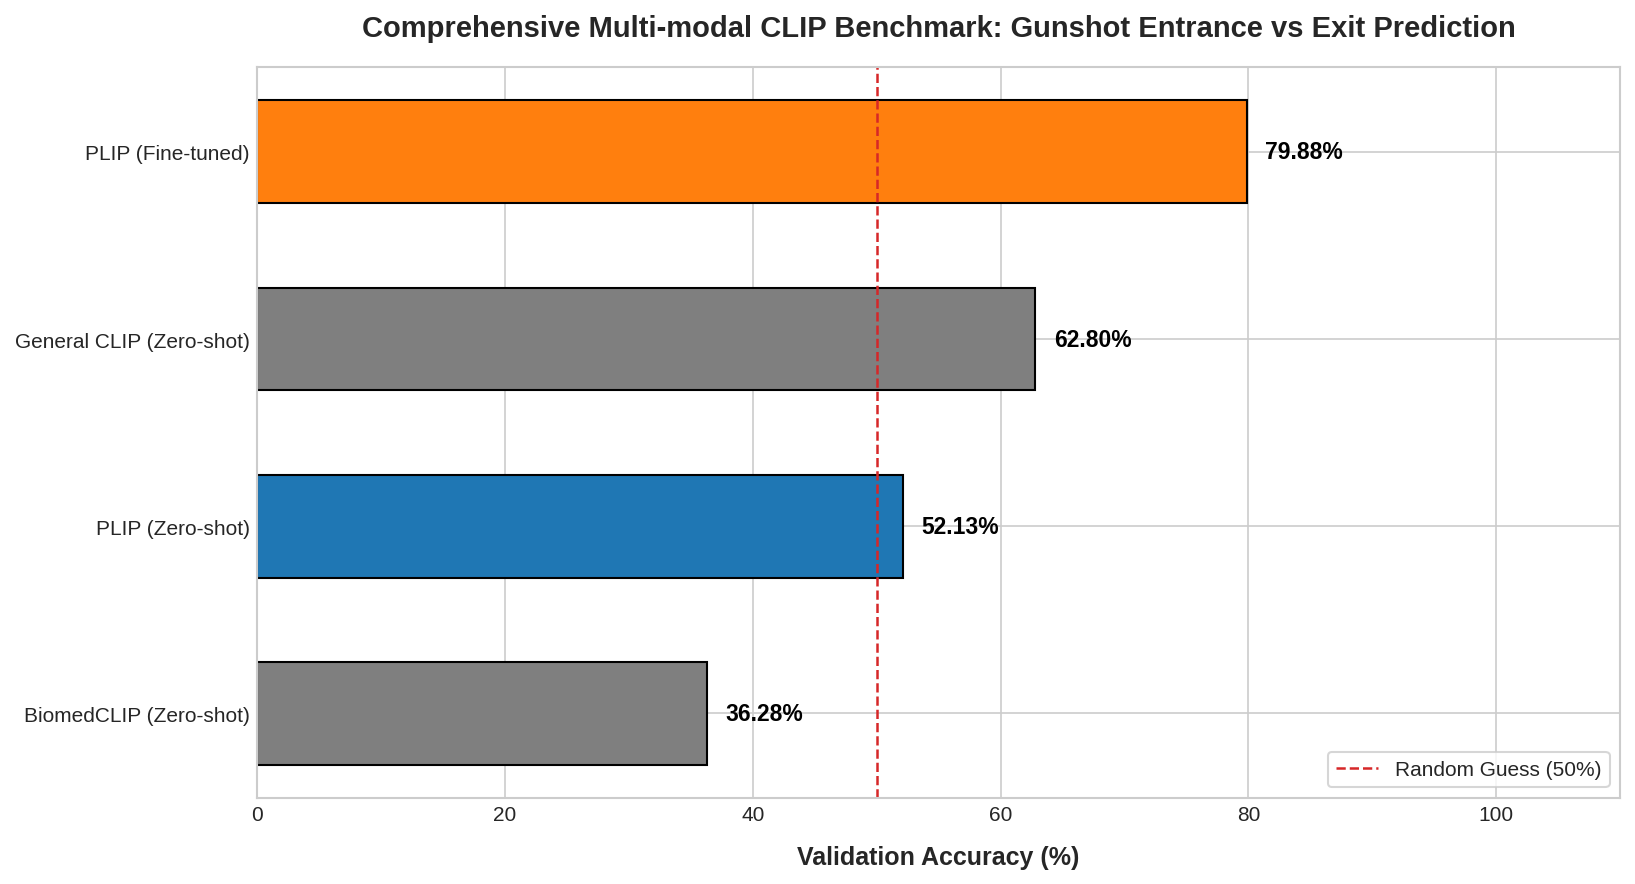


📊 폰트 경고가 제거된 클린 차트가 'CLIP_Forensic_Gunshot_4_Model_Master.png'로 업데이트되었습니다.


In [17]:
# ==============================================================================
# 📊 Step 9: CLIP Quartet Comprehensive Leaderboard & Advanced Visualization
# ==============================================================================
# 이모지를 제거하여 폰트 깨짐 경고를 원천 차단한 클린 논문 규격 시각화 단계입니다.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------------------------
# 1. 멀티모달 4대장 최종 스코어 보드 구축 (텍스트 클리닝)
# ------------------------------------------------------------------------------
model_benchmarks = {
    "Model Name": [
        "General CLIP (Zero-shot)",
        "BiomedCLIP (Zero-shot)",
        "PLIP (Zero-shot)",
        "PLIP (Fine-tuned)"
    ],
    "Domain Type": [
        "Multi-modal General",
        "Multi-modal Medical",
        "Multi-modal Pathology",
        "Our Forensic Adaptation"
    ],
    "Accuracy (%)": [
        62.80,  # General CLIP 실제 제로샷 성적
        36.28,  # BiomedCLIP 실제 제로샷 성적
        52.13,  # PLIP 오리지널 제로샷 성적
        79.88   # 방금 달성한 PLIP Fine-tuned 최고 성적
    ]
}

df_leaderboard = pd.DataFrame(model_benchmarks)
df_sorted = df_leaderboard.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("🏆 [CLIP Quartet Leaderboard] 총상 사입구/사출구 판별 멀티모달 4대장 최종 성적표")
print("=" * 80)
print(df_sorted.to_string(index=False))
print("=" * 80)

# ------------------------------------------------------------------------------
# 2. 깃허브 쇼케이스 및 학술 논문 규격 시각화 (Clean Font Setup)
# ------------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(11, 6), dpi=150)

# 파인튜닝 모델은 강조용 오렌지색, 제로샷 대조군들은 차분한 블루/그레이 계열로 칠합니다.
colors = ['#ff7f0e' if 'Fine-tuned' in name else '#1f77b4' if 'PLIP' in name else '#7f7f7f' for name in df_sorted["Model Name"]]

bars = ax.barh(df_sorted["Model Name"], df_sorted["Accuracy (%)"], color=colors, edgecolor='black', height=0.55)

# 차트 디테일 레이아웃 및 폰트 세팅 (타이틀과 모델명에서 이모지 완전 제거)
ax.invert_yaxis()  # 높은 성적이 맨 위로 오도록 배치
ax.set_xlim(0, 110)
ax.set_xlabel("Validation Accuracy (%)", fontsize=12, fontweight='bold', labelpad=10)
ax.set_title("Comprehensive Multi-modal CLIP Benchmark: Gunshot Entrance vs Exit Prediction", fontsize=14, fontweight='bold', pad=15)

# 각 바(Bar)의 끝에 정확도 수치 라벨 정밀 각인
for bar in bars:
    width = bar.get_width()
    ax.text(width + 1.5, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
            va='center', ha='left', fontsize=11, fontweight='bold',
            color='black')

# 이진 분류 무작위 확률(기준선) 가이드라인 추가
ax.axvline(x=50, color='#d62728', linestyle='--', linewidth=1.2, label='Random Guess (50%)')
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()

# 이미지 파일로 영구 저장 (Clean Version)
plt.savefig('CLIP_Forensic_Gunshot_4_Model_Master.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 폰트 경고가 제거된 클린 차트가 'CLIP_Forensic_Gunshot_4_Model_Master.png'로 업데이트되었습니다.")